In [1]:
!pip install pytrends pandas matplotlib seaborn prophet scikit-learn numpy


     ---------------------------------------- 0.0/50.6 kB ? eta -:--:--
     ------------------------------ ------- 41.0/50.6 kB 960.0 kB/s eta 0:00:01
     -------------------------------------- 50.6/50.6 kB 859.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.2/12.1 MB 3.9 MB/s eta 0:00:04
   - -------------------------------------- 0.4/12.1 MB 4.6 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/12.1 MB 4.7 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/12.1 MB 3.6 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/12.1 MB 4.1 MB/s eta 0:00:03
   --- ------------------------------------ 1.2/12.1 MB 4.4 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/12.1 MB 4.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.7/12.1 MB 4.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.9/12.1 MB 4.7 MB/s eta 0:00:03
   --

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [5]:
pytrends = TrendReq(hl='en-US', tz=330)

keywords = [
    "Artificial Intelligence",
    "Data Science",
    "Machine Learning",
    "Cloud Computing",
    "Cybersecurity"
]

pytrends.build_payload(keywords, timeframe='today 5-y')

In [15]:
data = pytrends.interest_over_time()

data = data.drop(columns=['isPartial'])

data.head()


,Artificial Intelligence,Data Science,Machine Learning,Cloud Computing,Cybersecurity
date,,,,,
2021-02-28,11,14,17,7,5
2021-03-07,10,14,16,6,6
2021-03-14,10,14,17,7,5
2021-03-21,10,14,16,7,5
2021-03-28,9,13,16,6,5


In [17]:
data.to_csv(r"C:\Users\DELL\Downloads\Google-Trends-Analysis-Project\data\google_trends_data.csv")

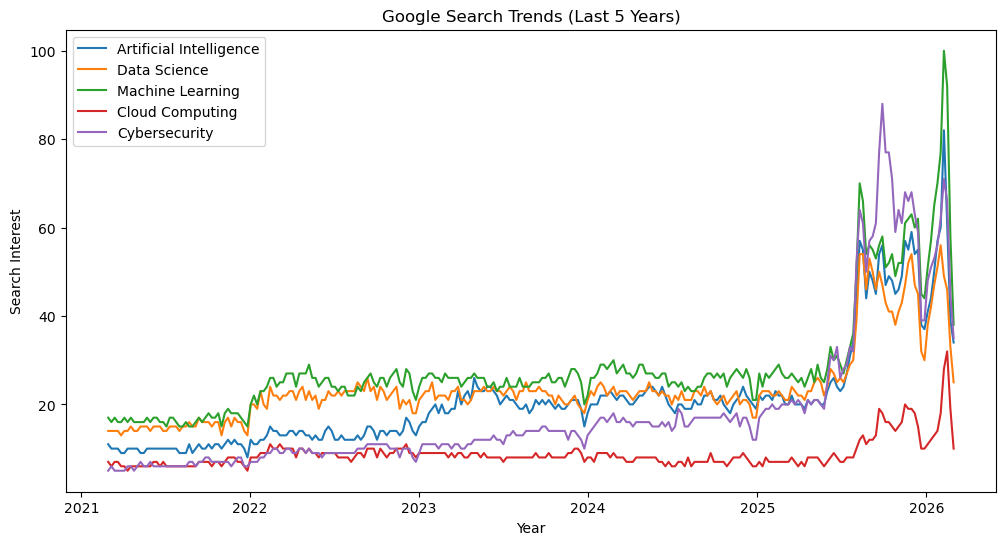

In [67]:
plt.figure(figsize=(12,6))

for column in data.columns:
    plt.plot(data.index, data[column], label=column)

plt.title("Google Search Trends (Last 5 Years)")
plt.xlabel("Year")
plt.ylabel("Search Interest")
plt.legend()
plt.savefig(r"C:\Users\DELL\Downloads\Google-Trends-Analysis-Project\outputs\Chart\google_trends_chart.png")
plt.show()

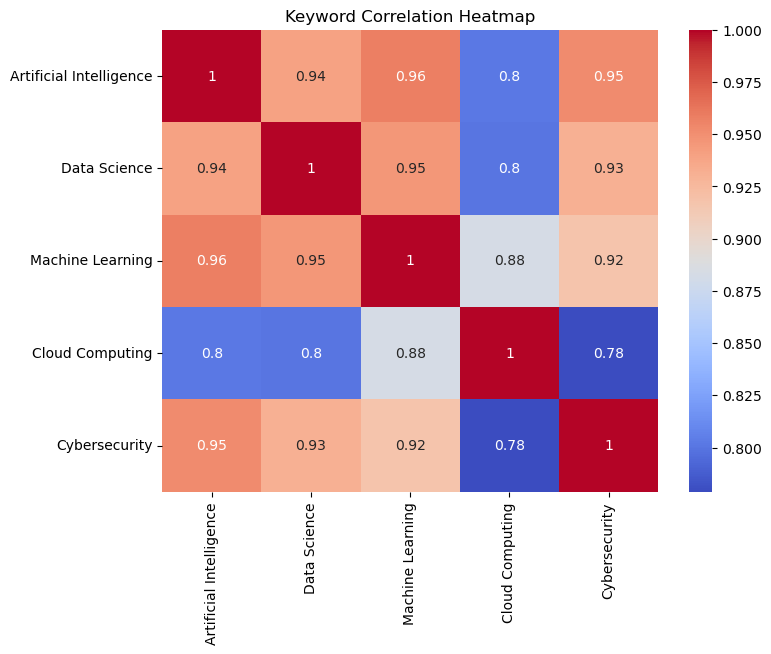

In [69]:
plt.figure(figsize=(8,6))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

plt.title("Keyword Correlation Heatmap")

plt.savefig(r"C:\Users\DELL\Downloads\Google-Trends-Analysis-Project\outputs\Chart\correlation_heatmap.png")

plt.show()

In [35]:
region = pytrends.interest_by_region()

region = region.sort_values(
    by="Artificial Intelligence",
    ascending=False
)

region.head(25)

,Artificial Intelligence,Data Science,Machine Learning,Cloud Computing,Cybersecurity
geoName,,,,,
Iran,39,15,40,3,3
Tanzania,38,21,19,9,13
Uzbekistan,36,24,19,6,15
Ethiopia,36,18,25,13,8
Philippines,35,20,16,11,18
Iraq,35,12,29,8,16
Oman,33,19,21,9,18
Pakistan,32,26,25,9,8
Uganda,31,23,18,16,12


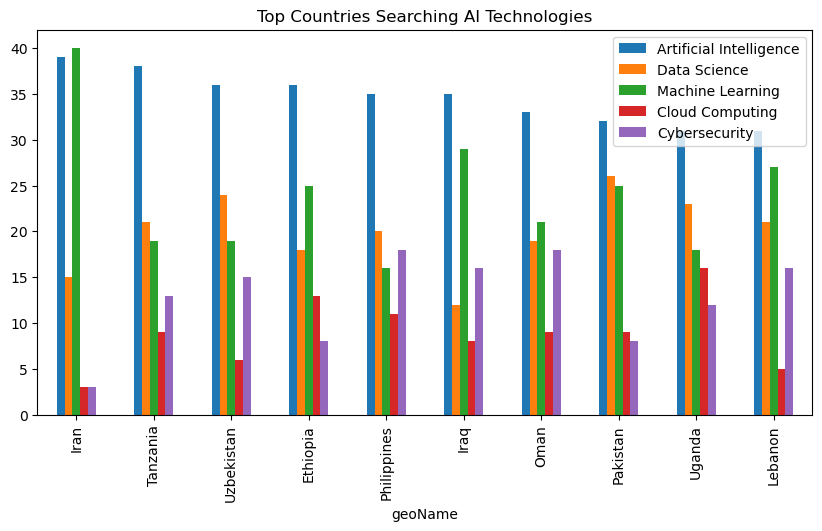

In [71]:
region.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Countries Searching AI Technologies")

plt.savefig(r"C:\Users\DELL\Downloads\Google-Trends-Analysis-Project\outputs\Chart\top_countries_ai_search.png")

plt.show()

In [55]:
related_queries = pytrends.related_queries()

related_queries["Artificial Intelligence"]["top"].head()

,query,value
0,artificial intelligence ai,100
1,ai,98
2,what is artificial intelligence,49
3,artificial intelligence news,42
4,artificial intelligence pdf,26


In [57]:
df = data.reset_index()

df = df[['date','Artificial Intelligence']]

df.columns = ['ds','y']

In [59]:
model = Prophet()

model.fit(df)

09:17:38 - cmdstanpy - INFO - Chain [1] start processing
09:17:38 - cmdstanpy - INFO - Chain [1] done processing


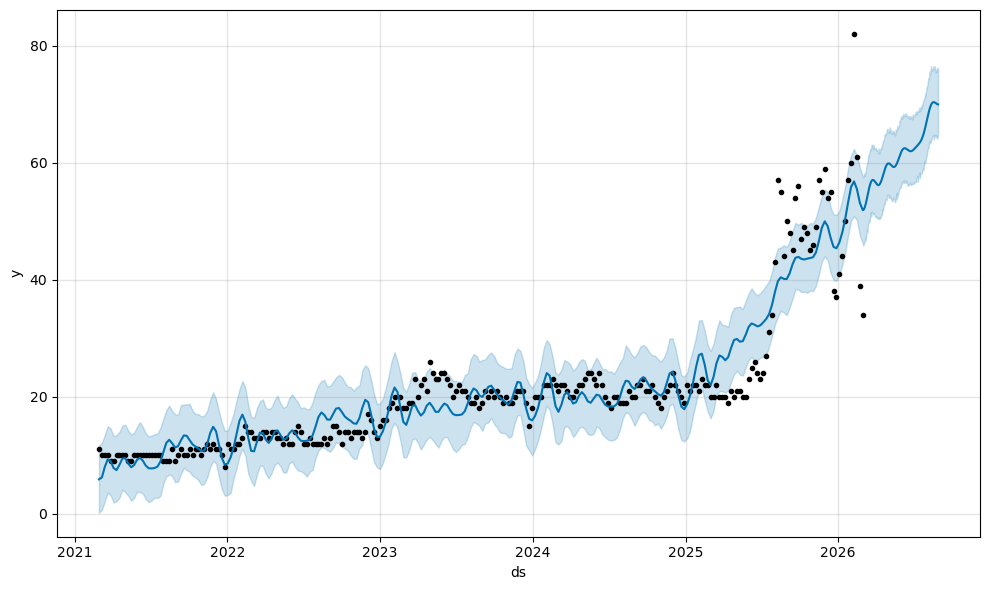

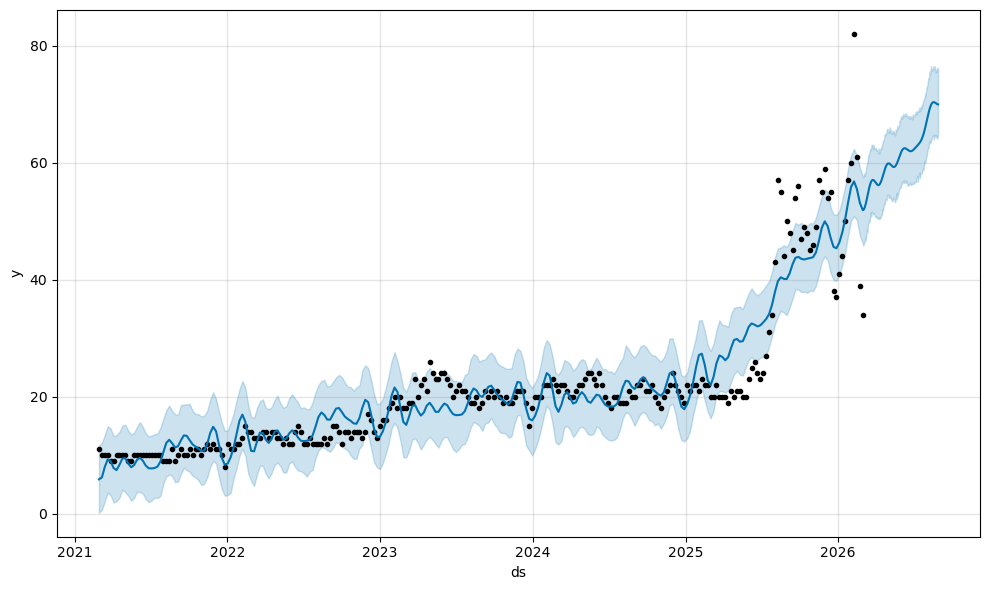

In [61]:
future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

model.plot(forecast)

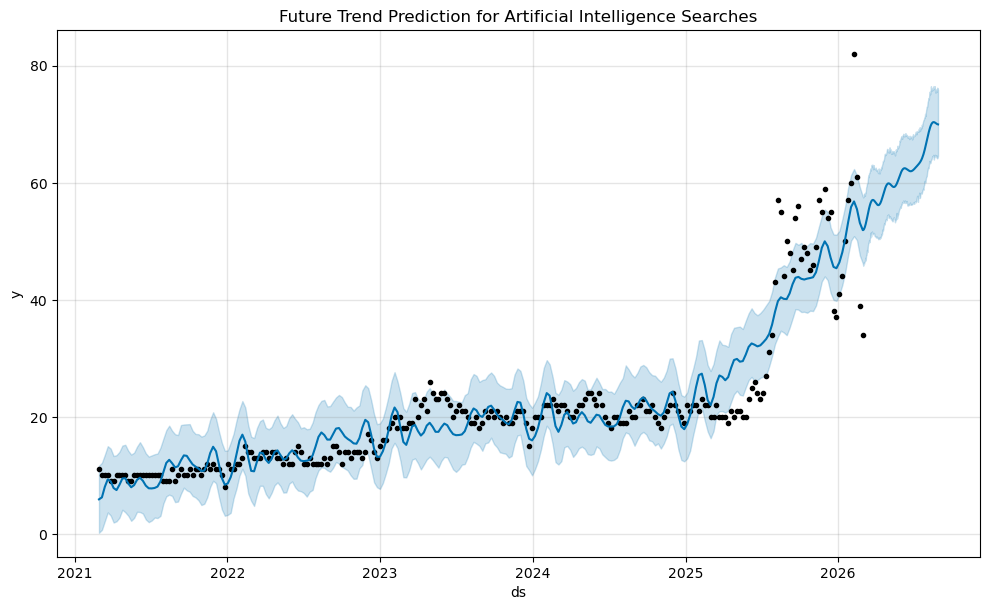

In [63]:
fig = model.plot(forecast)

plt.title("Future Trend Prediction for Artificial Intelligence Searches")

plt.show()

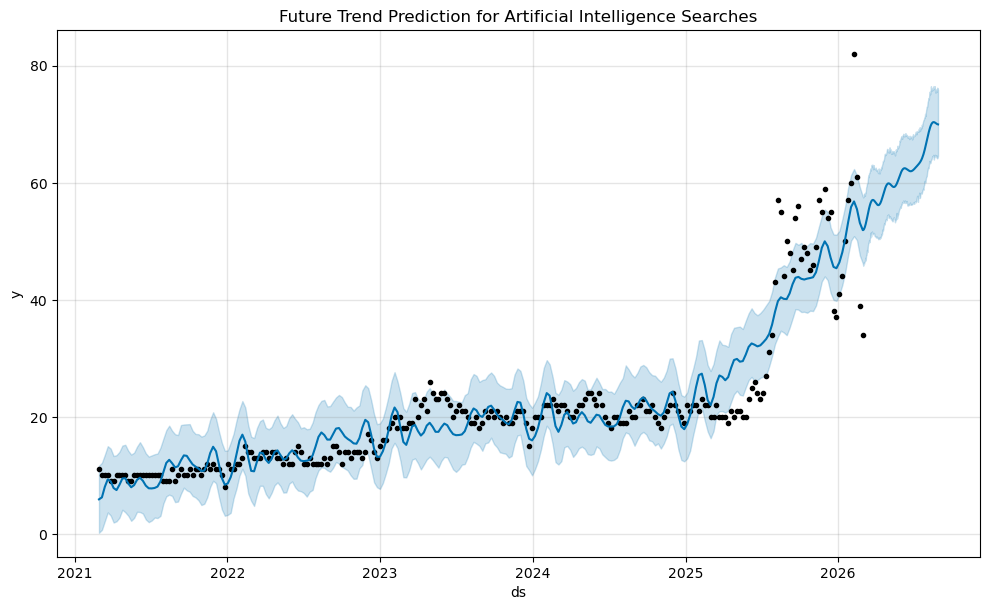

In [65]:
fig = model.plot(forecast)

plt.title("Future Trend Prediction for Artificial Intelligence Searches")

plt.savefig(r"C:\Users\DELL\Downloads\Google-Trends-Analysis-Project\outputs\Chart\ai_future_prediction.png")

plt.show()